# Gradient Descent
- Optimizer algo to find correct parameters(w,b)

In [39]:
import numpy as np
import matplotlib.pyplot as plt

$f_{w,b}(x^{(i)})$: $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
The cost function is:

$[
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( w \cdot x^{(i)} + b - y^{(i)} \right)^2
]$


In [40]:
def cost_func(w,b,X,Y):
    m=X.shape[0]
    y_hat=w*X+b
    final_cost=(1/(2*m))*np.sum((y_hat-Y)**2)
    return final_cost

The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

In [41]:
def compute_gradients(w,b,X,Y):
    m=X.shape[0]
    f_wb=w*X+b
    error = f_wb-Y
    dj_dw = (1/m)*np.sum(error*X)
    dj_db = (1/m)*np.sum(error)
    return dj_dw,dj_db


*gradient descent* was described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  

In [42]:
def gradient_descent(w_init,b_init,alpha,X,Y,num_iters):
    """
        w_init,b_init : random w,b
        alpha = learning rate
        num_iter = number of iterations
    """
    w=w_init
    b=b_init
    j_history=[]        # for visualization purpose only 
    for i in range(num_iters):
        dj_dw,dj_db=compute_gradients(w,b,X,Y)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
        
        if i%100==0:
            j_history.append(cost_func(w,b,X,Y))
    return w,b,j_history


In [43]:
# Normalized X_train (range ≈ -1.73 to +1.73)
X_train = np.array([
    -1.73, -1.66, -1.59, -1.52, -1.45, -1.38, -1.31, -1.24, -1.17, -1.10,
    -1.03, -0.96, -0.89, -0.82, -0.75, -0.68, -0.61, -0.54, -0.47, -0.40,
    -0.33, -0.26, -0.19, -0.12, -0.05,  0.02,  0.09,  0.16,  0.23,  0.30,
     0.37,  0.44,  0.51,  0.58,  0.65,  0.72,  0.79,  0.86,  0.93,  1.00,
     1.07,  1.14,  1.21,  1.28,  1.35,  1.42,  1.49,  1.56,  1.63,  1.70
])

# Normalized Y_train (range ≈ -1.6 to +1.6)
Y_train = np.array([
    -0.68, -1.60, -0.12,  0.22,  0.33, -0.19, -0.63, -0.03, -0.46,  0.16,
     0.17, -0.24,  1.21,  0.96, -0.14,  0.31,  0.50,  0.80, -0.03,  1.11,
     0.16,  0.45,  0.82,  0.84,  0.86,  0.18,  1.47,  0.10,  1.29,  1.29,
     0.36,  1.45,  1.57,  1.76,  0.66,  0.40,  0.87,  2.15,  2.22,  1.62,
     0.90,  1.81,  2.60,  2.17,  3.25,  1.58,  3.11,  2.56,  2.00,  3.35
])

In [52]:
w_init,b_init=100,0
alpha=0.001
iterations=10000
w_final,b_final,j_hist= gradient_descent(w_init,b_init,alpha,X_train,Y_train,iterations)


In [54]:
w_final,b_final

(np.float64(0.8926934086361528), np.float64(0.9239026651571415))

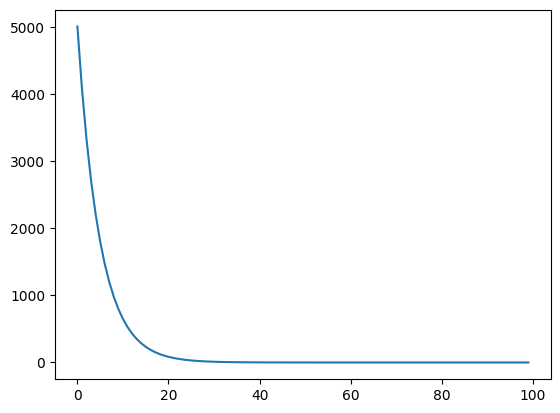

In [53]:
plt.plot(j_hist)